In [5]:
%pip install requests beautifulsoup4 lxml

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ------------------ --------------------- 1.8/4.1 MB 8.9 MB/s eta 0:00:01
   -------------------------------------- - 3.9/4.1 MB 8.8 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 8.0 MB/s  0:00:00

   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
   ---------------------------------------- 0/8 [urllib3]
 

In [6]:
import requests
import pandas as pd
from io import StringIO
from bs4 import BeautifulSoup

In [11]:
url = "https://en.wikipedia.org/wiki/List_of_largest_companies_in_the_United_States_by_revenue"

headers = {
    "User-Agent": "MyDataAnalysisBot/1.0 (your_email@example.com)"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Step 1: Use find_all to get a list of all matching tables
all_tables = soup.find_all('table', class_='wikitable sortable')
# Step 2: Create a list to store your DataFrames
dfs = []
# Step 3: Loop through each table found for table in all_tables:
for table in all_tables:
# Use StringIO to wrap the string version of the table
    df = pd.read_html(StringIO(str(table)))[0]
    dfs.append(df)

df = pd.read_html(StringIO(str(table)))[0]

pd.set_option('display.max_rows', 100)

print(df)

   Rank                Name                        Industry  \
0     1            Alphabet  Technology and cloud computing   
1     2               Apple                      Technology   
2     3  Berkshire Hathaway                    Conglomerate   
3     4           Microsoft  Technology and cloud computing   
4     5              Nvidia                      Technology   
5     6      Meta Platforms                      Technology   
6     7              Amazon      Retail and cloud computing   
7     8      JPMorgan Chase                      Financials   
8     9          ExxonMobil              Petroleum industry   
9    10     Bank of America                      Financials   

   Profits (USD millions)               Headquarters  
0                  100118  Mountain View, California  
1                   93736      Cupertino, California  
2                   88995            Omaha, Nebraska  
3                   88136        Redmond, Washington  
4                   72880    Sa

In [9]:
df

,Rank,Name,Industry,Profits (USD millions),Headquarters
0,1,Alphabet,Technology and cloud computing,100118,"Mountain View, California"
1,2,Apple,Technology,93736,"Cupertino, California"
2,3,Berkshire Hathaway,Conglomerate,88995,"Omaha, Nebraska"
3,4,Microsoft,Technology and cloud computing,88136,"Redmond, Washington"
4,5,Nvidia,Technology,72880,"Santa Clara, California"
5,6,Meta Platforms,Technology,62360,"Menlo Park, California"
6,7,Amazon,Retail and cloud computing,59248,"Seattle, Washington"
7,8,JPMorgan Chase,Financials,58471,"New York City, New York"
8,9,ExxonMobil,Petroleum industry,33680,"Spring, Texas"
9,10,Bank of America,Financials,27132,"Charlotte, North Carolina"


In [12]:
dfs [0]

,Rank,Name,Industry,Revenue (USD millions),Revenue growth,Employees,Headquarters
0,1,Walmart,Retail,680985,5.1%,2100000,"Bentonville, Arkansas"
1,2,Amazon,Retail and cloud computing,637959,11.0%,1556000,"Seattle, Washington"
2,3,UnitedHealth Group,Healthcare,400278,7.7%,400000,"Minnetonka, Minnesota"
3,4,Apple,Technology,391035,2.0%,164000,"Cupertino, California"
4,5,CVS Health,Healthcare,372809,4.2%,259500,"Woonsocket, Rhode Island"
5,6,Berkshire Hathaway,Conglomerate,371433,1.9%,392400,"Omaha, Nebraska"
6,7,Alphabet,Technology and cloud computing,350018,13.9%,183323,"Mountain View, California"
7,8,Exxon Mobil,Petroleum,349595,1.5%,60900,"Spring, Texas"
8,9,McKesson Corporation,Healthcare,308951,11.7%,48000,"Irving, Texas"
9,10,Cencora,Pharmacy wholesale,293959,12.1%,44000,"Conshohocken, Pennsylvania"


In [13]:
dfs [1]

,Rank,Name,Industry,Revenue (USD billions),Employees,Headquarters
0,1,Cargill,Food & Drink,154.00,155000,"Minnetonka, Minnesota"
1,2,Koch,Multicompany,125.00,120000,"Wichita, Kansas"
2,3,Publix Super Markets,Food Markets,59.70,260000,"Lakeland, Florida"
3,4,Mars,Food & Drink,55.00,150000,"McLean, Virginia"
4,5,H-E-B Grocery Company,Food Markets,49.57,175000,"San Antonio, Texas"
5,6,Reyes Holdings,"Food, Drink & Tobacco",44.00,36000,"Rosemont, Illinois"
6,7,Enterprise Mobility,Services,38.00,100000,"Clayton, Missouri"
7,8,Fidelity Investments,Insurance,32.70,78000,"Boston, Massachusetts"
8,9,Southern Glazer's Wine & Spirits,"Food, Drink & Tobacco",25.00,24000,"Miramar, Florida"
9,10,Cox Enterprises,Media,23.50,50000,"Atlanta, Georgia"


In [14]:
dfs [2]

,Rank,Name,Industry,Profits (USD millions),Headquarters
0,1,Alphabet,Technology and cloud computing,100118,"Mountain View, California"
1,2,Apple,Technology,93736,"Cupertino, California"
2,3,Berkshire Hathaway,Conglomerate,88995,"Omaha, Nebraska"
3,4,Microsoft,Technology and cloud computing,88136,"Redmond, Washington"
4,5,Nvidia,Technology,72880,"Santa Clara, California"
5,6,Meta Platforms,Technology,62360,"Menlo Park, California"
6,7,Amazon,Retail and cloud computing,59248,"Seattle, Washington"
7,8,JPMorgan Chase,Financials,58471,"New York City, New York"
8,9,ExxonMobil,Petroleum industry,33680,"Spring, Texas"
9,10,Bank of America,Financials,27132,"Charlotte, North Carolina"


In [18]:
df.columns

Index(['Rank', 'Name', 'Industry', 'Profits (USD millions)', 'Headquarters'], dtype='str')

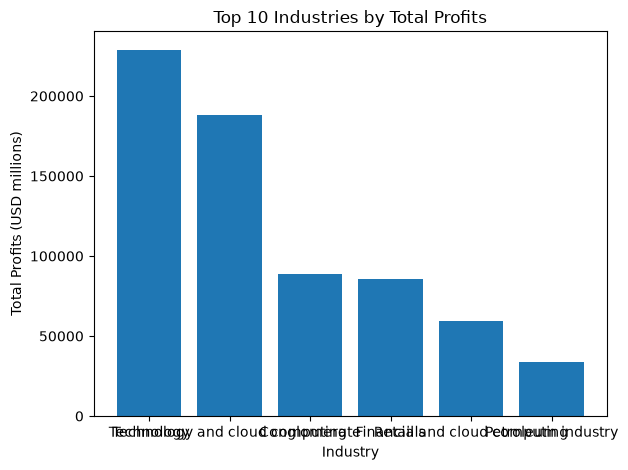

In [27]:
import matplotlib.pyplot as plt

# 1. Group by Industry and sum the profits
grouped_df = (
    df.groupby("Industry")["Profits (USD millions)"]
    .sum()
    .reset_index()
)

# 2. Sort and select top 10 groups
top10_groups = grouped_df.sort_values(by="Profits (USD millions)", ascending=False).head(15)

# 3. Plot the data
plt.figure()
plt.bar(top10_groups["Industry"], top10_groups["Profits (USD millions)"])
plt.xticks(rotation=0)
plt.xlabel("Industry")
plt.ylabel("Total Profits (USD millions)")
plt.title("Top 10 Industries by Total Profits")
plt.tight_layout()
plt.show()
